In [6]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################
params = FrostEvaporatorParameters(
    # Time
    time_step=1.0,  # [s]

    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    hydraulic_fan_power=50.0,  # [W]
    pressure_loss_fit_factor=1.0,  # [-]

    # Geometrie Parameters
    fin_pitch=0.008,  # [m]
    fin_height=0.4,  # [m]
    fin_length=0.8,  # [m]
    fin_thickness=0.00012,  # [m]
    fin_amount=200,  # [-]
    fin_thermal_conductivity=200.0,  # [W/mK]
    tube_outer_diameter=0.010,  # [m]
    tube_inner_diameter=0.006,  # [m]
    tube_layers=4,  # [-]
    tubes_per_layer=16,  # [-]
    tube_thermal_conductivity=400, # [W/mK]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################
refrigerant_inputs = RefrigerantInputs(
    h_in = 246000.0,  # [J/kg]
    p_eva = 3.3e5,  # [Pa]
    m_dot= 0.18,  # [kg/s]
)

# Define the inputs for the frost evaporator
air_inputs = AirInputs(
    T_in  = 272.15,  # [K]
    p_in  = 101325.0,  # [Pa]
    W_in  = 0.0047,  # [kg/kg]
    )

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)



#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("m_dot_frost_flux", 2e-9) # kg/m^2/s
state.hmt.set("T_frost_surface", 268)

state.air.set("T_out", 270.0)
state.air.set("W_out", 0.0006)
state.air.set("reynolds", 2000)

state.refrigerant.set("h_out", 150000.0)


frost_model.step_forward(state, inputs)

states_history = []
from tqdm import tqdm



for j in tqdm(range(2000)):
    converged = False  # Flag to track if we found a stable solution
    
    # --- 2. Inner loop to converge ---
    for i in range(100):
        T_prev = state.hmt.T_frost_surface
        
        # Run your model updates
        frost_model.update_properties(state, inputs)
        air_model.update_properties(state, inputs)
        refrigerant_model.update_properties(state, inputs)
        hmt_model.update_properties(state, inputs)
        thermo_model.update_properties(state, inputs)
        
        # Get the *new* value
        T_new = state.hmt.T_frost_surface
        
        # --- 3. The convergence check ---
        error = abs(T_new - T_prev)
        if error < 5e-3 :
            converged = True  # We found a stable solution!
            break             # Exit the inner loop
    
    # --- 4. Handle non-convergence ---
    if not converged:
        print(f"Warning: Solution did not converge at outer step j = {j}")


    states_history.append(state.copy())
    
    # Now that we have a converged state, take the physical step forward
    frost_model.step_forward(state, inputs)

Model initialized with fluid: Propane


100%|██████████| 2000/2000 [00:14<00:00, 138.00it/s]


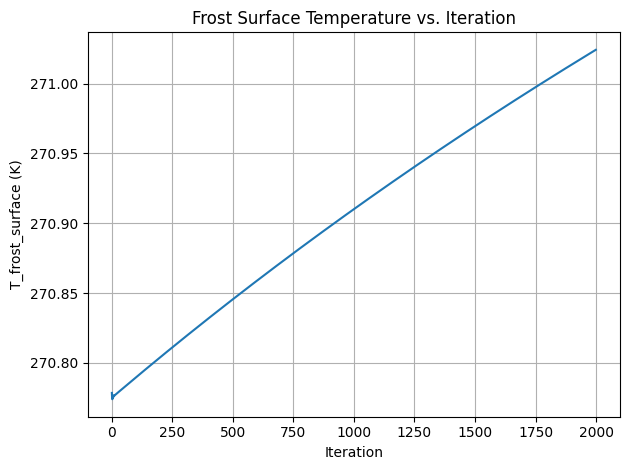

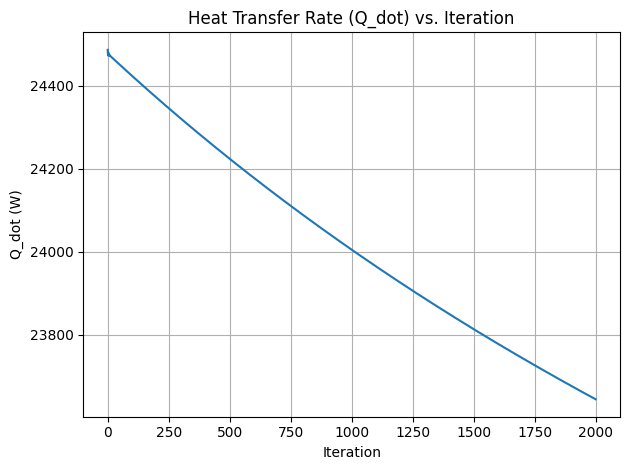

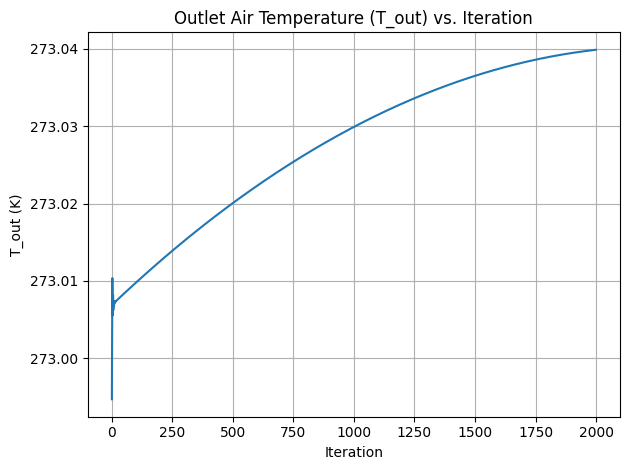

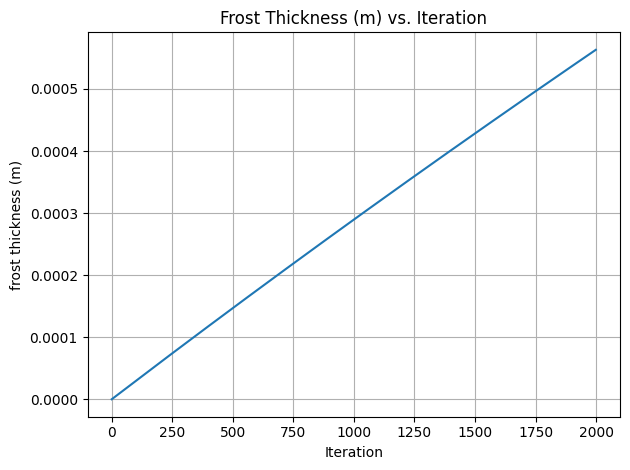

In [7]:
#############################################################################
# Extract Data for Plotting
#############################################################################
# Create an x-axis (iterations)

iterations = range(len(states_history))

# Extract the history for each variable
T_frost_surface_history = [s.hmt.T_frost_surface for s in states_history]
Q_dot_history = [s.hmt.Q_dot for s in states_history]
T_out_history = [s.air.T_out for s in states_history]
thickness_history = [s.frost.thickness for s in states_history]

#############################################################################
# Generate Plots
#############################################################################

# Plot 1: state.hmt.T_frost_surface
plt.figure() # Create a new figure
plt.plot(iterations, T_frost_surface_history)
plt.xlabel("Iteration")
plt.ylabel("T_frost_surface (K)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Frost Surface Temperature vs. Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 2: state.hmt.Q_dot
plt.figure()
plt.plot(iterations, Q_dot_history)
plt.xlabel("Iteration")
plt.ylabel("Q_dot (W)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Heat Transfer Rate (Q_dot) vs. Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()



# Plot 4: state.air.T_out
plt.figure()
plt.plot(iterations, T_out_history)
plt.xlabel("Iteration")
plt.ylabel("T_out (K)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Outlet Air Temperature (T_out) vs. Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 5: state.refrigerant.h_out
plt.figure()
plt.plot(iterations, thickness_history)
plt.xlabel("Iteration")
plt.ylabel("frost thickness (m)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Frost Thickness (m) vs. Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()



In [2]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from

# Define the parameters for the frost evaporator
params = FrostEvaporatorParameters(
    # Time
    time_step=1.0,  # [s]

    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    hydraulic_fan_power=50.0,  # [W]
    pressure_loss_fit_factor=1.0,  # [-]

    # Geometrie Parameters
    fin_pitch=0.004,  # [m]
    fin_height=0.4,  # [m]
    fin_length=0.8,  # [m]
    fin_thickness=0.0002,  # [m]
    fin_amount=60,  # [-]
    fin_thermal_conductivity=200.0,  # [W/mK]
    tube_outer_diameter=0.010,  # [m]
    tube_inner_diameter=0.006,  # [m]
    tube_layers=5,  # [-]
    tubes_per_layer=4,  # [-]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)



refrigerant_inputs = RefrigerantInputs(
    h_in = 400000.0,  # [J/kg]
    p_eva = 5e5,  # [Pa]
    m_dot= 0.02,  # [kg/s]
)
air_inputs = AirInputs(
    T_in  = 273.15,  # [K]
    p_in  = 101325.0,  # [Pa]
    W_in  = 0.001,  # [kg/kg]
)

state = FrostEvaporatorState()

state.refrigerant.h_out = 400000.0  # [J/kg]

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)

from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
# Create the models

refrigerant_model = RefrigerantModel(params, propane_RP)

refrigerant_model.update_properties(state, inputs)

state.refrigerant.h_conv

SyntaxError: invalid syntax (2769171751.py, line 20)

In [ ]:
# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("m_dot_frost_flux", 2e-4) # kg/m^2/s

# Temperature sweep from 265K to 270K
temperatures_frost = np.linspace(265, 270, 100)

# Arrays to store results
thicknesses = []
densitys    = []
k_frosts    = []
flow_areas_air        = []

for T_frost in temperatures_frost:
    # Update the Frost Temperature - would be done by hmt.py
    state.hmt.set("T_frost_surface", T_frost)

    # Blue Boxes (This will be in a Iterative Loop later)
    frost_model.update_properties(state, inputs)

    # Green Boxes (Update after 1s timestep)
    frost_model.step_forward(state, inputs)

    # Store the results
    thicknesses.append(state.frost.thickness)
    densitys.append(state.frost.density)
    k_frosts.append(state.frost.k_frost)
    flow_areas_air.append(state.frost.flow_area_air)



fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axs[0].plot(thicknesses, marker='.', linestyle='-')
axs[0].set_ylabel("Thickness (m)")

axs[1].plot(densitys, marker='.', linestyle='-')
axs[1].set_ylabel("Density (kg/m³)")

axs[2].plot(k_frosts, marker='.', linestyle='-')
axs[2].set_ylabel("k_frost (W/mK)")
axs[2].set_xlabel("Time (s)")

axs[3].plot(flow_areas_air, marker='.', linestyle='-')
axs[3].set_ylabel("Air Flow Area (m²)")
axs[3].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()